<a href="https://colab.research.google.com/github/KarlyHdzC/Mineria_de_datos/blob/main/F08_Mi_primera_red_neuronal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Minería de Datos - Universidad Anáhuac
## Machine Learning - Libreta 7
**Profesor: Dr. Farid Krayem Pineda**

Alumna: Karla Beatriz Hernandez Castro

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Lista de valores en Celsius para entrenamiento
celsius_train = np.array([-40, -10, 0, 10, 20, 25, 30, 37, 50, 100], dtype=float)

# Lista de valores en Fahrenheit para entrenamiento (F = C * 1.8 + 32)
fahrenheit_train = celsius_train * 1.8 + 32

celsius = celsius_train # Ahora esta variable representa los grados Celsius
fahrenheit = fahrenheit_train # Ahora esta variable representa los grados Fahrenheit

print("Datos de entrada (Celsius):", celsius)
print("Datos de salida (Fahrenheit):", fahrenheit)

Datos de entrada (Celsius): [-40. -10.   0.  10.  20.  25.  30.  37.  50. 100.]
Datos de salida (Fahrenheit): [-40.   14.   32.   50.   68.   77.   86.   98.6 122.  212. ]


In [ ]:
# Aquí se define la arquitectura de la red neuronal
# Entrada (1) → [3 neuronas] → [3 neuronas] → [1 neurona]

oculta1 = tf.keras.layers.Dense(units=2, input_shape=[1])
oculta2 = tf.keras.layers.Dense(units=2)
salida = tf.keras.layers.Dense(units=1)
modelo = tf.keras.Sequential([oculta1, oculta2, salida])

In [ ]:
# Adam es un algortimo que optimiza los pesos ajustando gradientes
# 0.1 es como se mueve el learning rate, muy pequeño aprende lento, muy grande puede no ser óptimo
# Mean squared mide el error entre lo que mide el modelo y la realidad

modelo.compile(
    optimizer=tf.keras.optimizers.Adam(0.01),
    loss='mean_squared_error'
)

In [ ]:
print("Comenzando entrenamiento...")
# celsius: Datos de entrada (X), es decir, lo que el modelo usará para hacer predicciones.
# fahrenheit: Datos de salida (y), lo que el modelo debe aprender a predecir a partir de los Celsius.

historial = modelo.fit(celsius, fahrenheit, epochs=1000, verbose=True) # Si no quieres ver las acciones se establece en false.
print("Modelo entrenado!")

Comenzando entrenamiento...
Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 975ms/step - loss: 10309.7070
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 10202.5068
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 10100.5645
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 10003.8760
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 9912.4131
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 9826.1094
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 9744.8613
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 9668.5234
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 9596.8906
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 9529.7002
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 9466.6104
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 9407.2041
Epoch 13/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 9350.9795
Epoch 14/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 9297.3

¿Qué es historial.history["loss"]?
historial es el objeto devuelto por modelo.fit(...).

.history es un diccionario que guarda el historial del entrenamiento.

"loss" contiene una lista con los valores de pérdida en cada época.

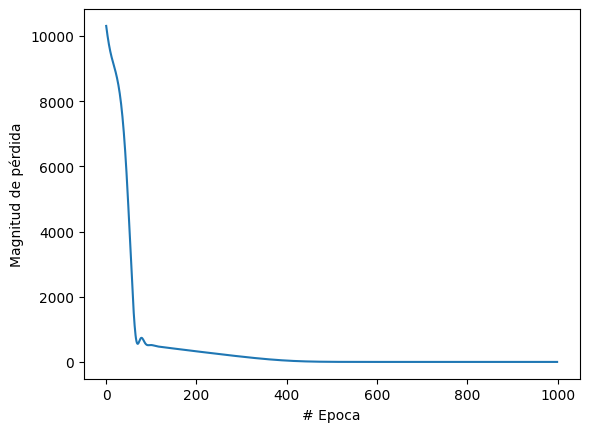

In [ ]:
## Gráficamos cuántas épocas le tomo al modelo poder entrenarse ##
import matplotlib.pyplot as plt
plt.xlabel("# Epoca")
plt.ylabel("Magnitud de pérdida")
plt.plot(historial.history["loss"])

#### ✅ ¿Qué está pasando aquí?

- `modelo.predict(...)` usa el modelo ya entrenado para **predecir valores de salida** a partir de nuevas entradas.
- `np.array([100, 66])`:
  - Es un arreglo con dos valores en Celsius (por ejemplo, 100 °C y 66 °C).
  - El modelo los convierte en Fahrenheit, aprendiendo de los datos previos.

In [ ]:
print("Hagamos una predicción!")
entrada = np.array([20, 30, -5], dtype=float) # Nuevos valores de entrada en Celsius
resultado = modelo.predict(entrada)

for i in range(len(entrada)):
    print(f"{entrada[i]:.2f} Celsius son aproximadamente {resultado[i][0]:.2f} Fahrenheit")

Hagamos una predicción!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
20.00 Celsius son aproximadamente 68.00 Fahrenheit
30.00 Celsius son aproximadamente 86.00 Fahrenheit
-5.00 Celsius son aproximadamente 23.00 Fahrenheit


✅ ¿Qué hace?
Usa los mismos datos de entrenamiento (kilogramos, libras) para evaluar el rendimiento del modelo.

Calcula el valor de la función de pérdida que definimos antes (mean_squared_error).

Devuelve un solo número: el error cuadrático medio (MSE).

⚠️ Como estamos usando los mismos datos de entrenamiento, no es una evaluación general del modelo, sino una medida de qué tan bien memorizó o ajustó los datos de entrenamiento.

In [ ]:
## Evaluación del modelo con los mismos datos de entrenamiento ##
loss = modelo.evaluate(celsius, fahrenheit)
rmse = np.sqrt(loss)

print("Pérdida del modelo (MSE):", loss)
print("Error cuadrático medio (RMSE):", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - loss: 3.0970e-09
Pérdida del modelo (MSE): 3.0970113140682543e-09
Error cuadrático medio (RMSE): 5.565079796434418e-05


✅ MSE (Mean Squared Error)
Es el promedio de los errores al cuadrado.

Penaliza más los errores grandes.

Unidad: es el cuadrado de la unidad original (por ejemplo, Fahrenheit²).

Se usa comúnmente como función de pérdida durante el entrenamiento.

✅ RMSE (Root Mean Squared Error)
Es la raíz cuadrada del MSE.

Tiene la misma unidad que los datos originales (por ejemplo, Fahrenheit).

Es más intuitivo: representa el promedio de error en las mismas unidades que las predicciones.

📊 Ejemplo sencillo:
Si el MSE es 0.55 Fahrenheit² → el RMSE sería aproximadamente 0.74 Fahrenheit.

Eso significa: en promedio, el modelo se equivoca 0.74 Fahrenheit por predicción.

* un RMSE ≈ 0.745, lo que significa que el modelo se equivoca en promedio menos de un grado Fahrenheit por predicción.

* Un **MSE** cercano a 0 indica que el modelo hace predicciones muy precisas sobre los datos de entrenamiento.

* Sin embargo, si el error es demasiado bajo, podría significar que el modelo memoriza los datos en lugar de generalizar bien a nuevos valores (sobreajuste).

* Para saber si realmente el modelo generaliza bien, sería ideal probarlo con datos nuevos que no haya visto antes.

In [ ]:
## Evaluar el modelo con nuevos datos ##
# Nuevo conjunto de datos de prueba en Celsius
X_test = np.array([5, 15, 25, 35, 45, 55, -5, -15, 0, 100, 2, 70, 80], dtype=float)
# Sus equivalentes en Fahrenheit (F = C * 1.8 + 32)
Y_test = X_test * 1.8 + 32

loss_test = modelo.evaluate(X_test, Y_test)
rmse_test = np.sqrt(loss_test)

print("Pérdida del modelo en datos de prueba (MSE):", loss_test)
print("Error cuadrático medio en datos de prueba (RMSE):", rmse_test)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 2.3762e-09
Pérdida del modelo en datos de prueba (MSE): 2.376229879530456e-09
Error cuadrático medio en datos de prueba (RMSE): 4.8746588388629374e-05


✅ Interpretación:
El error en datos de prueba (aproximadamente `4.87e-05` grados Fahrenheit) es muy cercano al error en entrenamiento (aproximadamente `5.57e-05` grados Fahrenheit), lo cual es excelente.

Esto indica que el modelo:

*   Aprendió perfectamente la relación Celsius ↔ Fahrenheit.
*   Generaliza correctamente a nuevos datos que no ha visto.
*   No hay señales de sobreajuste ni subajuste, sino una alta precisión.

In [ ]:
## Gráfico para ver la comparativa entre los datos reales y las predicciones ##

# Hacer predicciones en los datos de prueba
predicciones = modelo.predict(X_test)

# Mostrar comparaciones
for i in range(len(X_test)):
    print(f"Celsius: {X_test[i]:.2f}, Fahrenheit real: {Y_test[i]:.2f}, Predicción: {predicciones[i][0]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Celsius: 5.00, Fahrenheit real: 41.00, Predicción: 41.00
Celsius: 15.00, Fahrenheit real: 59.00, Predicción: 59.00
Celsius: 25.00, Fahrenheit real: 77.00, Predicción: 77.00
Celsius: 35.00, Fahrenheit real: 95.00, Predicción: 95.00
Celsius: 45.00, Fahrenheit real: 113.00, Predicción: 113.00
Celsius: 55.00, Fahrenheit real: 131.00, Predicción: 131.00
Celsius: -5.00, Fahrenheit real: 23.00, Predicción: 23.00
Celsius: -15.00, Fahrenheit real: 5.00, Predicción: 5.00
Celsius: 0.00, Fahrenheit real: 32.00, Predicción: 32.00
Celsius: 100.00, Fahrenheit real: 212.00, Predicción: 212.00
Celsius: 2.00, Fahrenheit real: 35.60, Predicción: 35.60
Celsius: 70.00, Fahrenheit real: 158.00, Predicción: 158.00
Celsius: 80.00, Fahrenheit real: 176.00, Predicción: 176.00


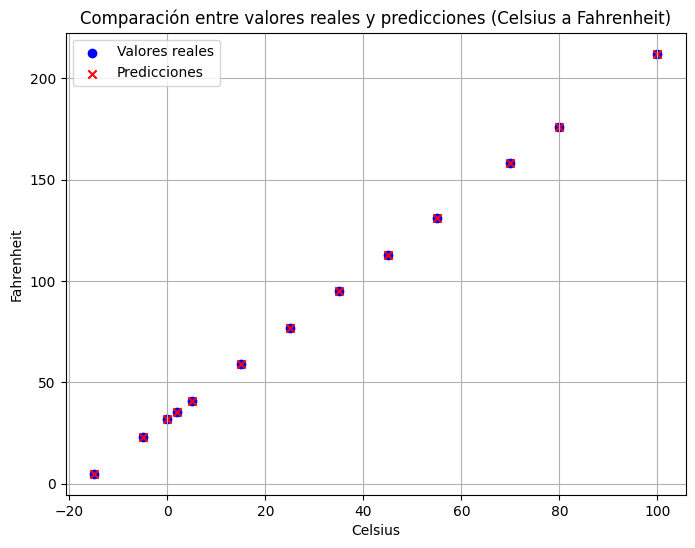

In [ ]:
# Crear gráfico de dispersión
plt.figure(figsize=(8,6))
plt.scatter(X_test, Y_test, label="Valores reales", color="blue")
plt.scatter(X_test, predicciones, label="Predicciones", color="red", marker='x')

# Etiquetas y leyenda
plt.xlabel("Celsius")
plt.ylabel("Fahrenheit")
plt.title("Comparación entre valores reales y predicciones (Celsius a Fahrenheit)")
plt.legend()
plt.grid()

# Mostrar gráfico
plt.show()